In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt 
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from Datasets.datasetTUAB import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [02:04<00:00, 17.06it/s]


Dataset Loaded. Length of Train Dataset:  269124
Loading 253 folders


100%|██████████| 253/253 [00:12<00:00, 20.13it/s]

Dataset Loaded. Length of Validation Dataset:  30606


In [8]:
print(finetune_eval_dataset[0]['graph'].x.shape)
print(finetune_eval_dataset[0]['delta'].shape)
print(finetune_eval_dataset[0]['theta'].shape)
print(finetune_eval_dataset[0]['alpha'].shape)
print(finetune_eval_dataset[0]['beta'].shape)
print(finetune_eval_dataset[0]['gamma'].shape)

(19, 1280)
torch.Size([19, 41])
torch.Size([19, 41])
torch.Size([19, 81])
torch.Size([19, 161])
torch.Size([19, 320])


In [9]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=2048, num_workers=8, shuffle=True, persistent_workers=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=2048, num_workers=8, shuffle=True, persistent_workers=True)
print(len(finetune_train_loader), len(finetune_eval_loader))
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

132 15


In [13]:
class WaveletEncoderDecoder(nn.Module):
    def __init__(self, num_channels, sub_patch_size, heads, super_patch_seq_len, encoded_h, device):
        super(WaveletEncoderDecoder, self).__init__()
        self.num_channels = num_channels
        self.channel_dropout = nn.Dropout1d(0.1)
        self.patch_size = sub_patch_size
        self.stride = self.patch_size // 2
        self.device = device
        self.heads = heads
        self.encoded_h = encoded_h
        self.seq_len = super_patch_seq_len

        self.act = nn.GELU()
        L_out = self.seq_len + 2 * (0) - 1 * ((self.patch_size) - 1) - 1
        L_out = floor(L_out / (self.stride)) + 1
        self.patch_embedder = nn.Conv1d(in_channels=19, out_channels=19, kernel_size=self.patch_size, stride=self.stride, groups=1).to(self.device)
        self.patch_embedder_lin = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        #self.gnn_channel_encoder = SplineConv(L_out, self.seq_len, dim=1, kernel_size=3).to(self.device)
        self.gnn_channel_encoder = GATConv(L_out, L_out, heads=self.heads, concat=False).to(self.device)
        self.gnn_lin1 = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        self.layer_norm1 = nn.LayerNorm((19, L_out))
        self.layer_norm2 = nn.LayerNorm((19, L_out))

        L_out = L_out + 2 * (0) - 1 * (2 - 1) - 1
        L_out = floor(L_out / 1) + 1
        self.patch_embedder2 = nn.Conv1d(in_channels=19, out_channels=encoded_h, kernel_size=2, stride=1, groups=1, padding=0)
        self.patch_embedder2_lin = nn.Sequential(self.act, nn.Linear(L_out, L_out))

        # Decoders
        L_out = (L_out - 1) * self.stride - 2 * 0 + 1 * (1 - 1) + 0 + 1
        self.up1 = nn.ConvTranspose1d(in_channels=encoded_h, out_channels=encoded_h * 4, kernel_size=1, stride=self.stride, groups=1)
        L_out = (L_out - 1) * (1) - 2 * 0 + 1 * (1 - 1) + 0 + 1
        self.up2 = nn.ConvTranspose1d(in_channels=encoded_h * 4, out_channels=19, kernel_size=1, stride=1, groups=19)
        self.up3 = nn.Sequential(self.act, nn.Linear(L_out, self.seq_len))

    def getEncoderParamCount(self):
        patch_embedder_count = sum(p.numel() for p in self.patch_embedder.parameters() if p.requires_grad)
        gnn_encoder_count = sum(p.numel() for p in self.gnn_channel_encoder.parameters() if p.requires_grad)
        return patch_embedder_count + gnn_encoder_count

    def getDecoderParamCount(self):
        up1_count = sum(p.numel() for p in self.up1.parameters() if p.requires_grad)
        up2_count = sum(p.numel() for p in self.up2.parameters() if p.requires_grad)
        up3_count = sum(p.numel() for p in self.up3.parameters() if p.requires_grad)
        return up1_count + up2_count + up3_count

    def forward(self, graph, x):
        # x: [Batch Size, Channels, Time Steps]
        x = self.channel_dropout(x)
        x = self.patch_embedder(x)
        x = self.patch_embedder_lin(x)
        x = self.layer_norm1(x)
        edge_index = graph.edge_index.to(self.device)
        edge_dist = graph.edge_attr.to(self.device)
        gnn_channel_encoder_input1 = x.view(-1, x.shape[-1])
        channel_encoding = self.gnn_channel_encoder(gnn_channel_encoder_input1, edge_index, edge_dist)
        x = x + channel_encoding.view(x.shape[0], -1, channel_encoding.shape[-1])
        x = self.layer_norm2(x)
        x = self.gnn_lin1(x)
        x = self.patch_embedder2(x)
        x = self.patch_embedder2_lin(x)

        decoding = self.up1(x)
        decoding = self.channel_dropout(decoding)
        decoding = self.up2(decoding)
        decoding = self.up3(decoding)
        return x, decoding

'''
Initialize Encoders for each wavelet band and 
put them into a single object.
'''
class EncoderDecoder(nn.Module):
    def __init__(self, device):
        super(EncoderDecoder, self).__init__()
        self.device = device
        self.encoder_decoders = nn.ParameterDict({
            'delta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=4,
                    encoded_h=38,
                    heads=1,
                    super_patch_seq_len=41,
                    device = device
                    ),

            'theta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=4,
                    encoded_h=38,
                    heads=1,
                    super_patch_seq_len=41,
                    device = device
                    ),
            'alpha': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=8,
                    encoded_h=38,
                    heads=1,
                    super_patch_seq_len=81,
                    device = device 
                    ),

            'beta': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size=16,
                    encoded_h=38,
                    heads=1,
                    super_patch_seq_len = 161,
                    device = device
                    ),

            'gamma': WaveletEncoderDecoder(
                    num_channels = 19,
                    sub_patch_size = 32,
                    encoded_h = 76,
                    heads=1,
                    super_patch_seq_len=320,
                    device = device
                    ),
        })

    def forward(self, graph, data):
        assert data.keys() == self.encoder_decoders.keys()
        output = {}
        for band, band_decomposition in data.items():
            output[band] = self.encoder_decoders[band](graph, band_decomposition)
        return output

    def freeze_features(self, unfreeze=False, finetuning=False):
        for param in self.parameters():
            param.requires_grad = unfreeze
        if finetuning:
            self.mask_replacement.requires_grad = False

In [14]:
class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super(FinetuneDecoder, self).__init__()

        self.max_pool = nn.AvgPool1d(6, stride=3) 
        L_out = 18 + 2 * (0) - 1 * (6 - 1) - 1
        L_out = floor((L_out / 3) + 1)

        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'theta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'alpha': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'beta':  nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'gamma': nn.Sequential(nn.GELU(), nn.Linear(76 * 18, 19)),
        })

        self.band_decoders_out = nn.Sequential(nn.LayerNorm(95), nn.GELU(), nn.Linear(95, 95))
        self.final_decoder = nn.Linear(95, 1)

    def forward(self, x):
        band_decodings = []
        for band, (encodings, decodings) in x.items():
            #encodings = self.max_pool(encodings) 
            encodings = encodings.view(encodings.shape[0], -1)
            band_decoding = self.band_decoders[band](encodings)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)
        band_decodings = self.band_decoders_out(band_decodings)
        return self.final_decoder(band_decodings)



In [15]:
model = EncoderDecoder(device).to(device)
model_decoder = FinetuneDecoder(device).to(device)
#state_dict = torch.load("/home/hice1/mchen439/scratch/models/MENDREncoder3.pt")
#model.load_state_dict(state_dict)
optim_params = []
optim_params += list(model.parameters())
optim_params += list(model_decoder.parameters())
optimizer = MixOptimizer(torch.optim.AdamW(optim_params, lr=1e-3))
optimizer.set_scheduler_t0(len(finetune_train_loader))
aggregator = UPGrad(pref_vector=torch.tensor([1e3, 0.01, 0.1, 1, 10, 100]).to(device))
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))
total_encoder_params = 0
total_decoder_params = 0
for band in BANDS:
    print(f'{band} Encoder Params: {model.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.encoder_decoders[band].getDecoderParamCount()}')
    total_encoder_params += model.encoder_decoders[band].getEncoderParamCount()
    total_decoder_params += model.encoder_decoders[band].getDecoderParamCount()
print("Total Encoder Params: ", total_encoder_params)
print("Total Decoder Params: ", total_decoder_params)

Set Cosine Annealing with Warm Restarts optimizer T_0 to: 132
Total parameters: 213558
Total parameters: 87477
delta Encoder Params: 1881
delta Decoder Params: 7575
theta Encoder Params: 1881
theta Decoder Params: 7575
alpha Encoder Params: 3325
alpha Decoder Params: 11769
beta Encoder Params: 6213
beta Decoder Params: 28317
gamma Encoder Params: 11989
gamma Decoder Params: 111411
Total Encoder Params:  25289
Total Decoder Params:  166647


In [16]:
def calculate_band_loss(inputs, outputs, band_model, loss_fn):
    loss = loss_fn(inputs, outputs)
    return loss

In [17]:
def train_one_epoch(model, epoch, decoder, optimizer, task_loss_fn, recon_loss_fn, train_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.train()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		data = next(data_iterator)

		relevant_bands = [data['delta'].float().to(device),
		 				  data['theta'].float().to(device),
						  data['alpha'].float().to(device),
						  data['beta'].float().to(device),
						  data['gamma'].float().to(device)]

		#relevant_bands = [_std_norm(x) for x in relevant_bands]

		inputs = dict(zip(BANDS, relevant_bands))
		encoder_outputs = model(data['graph'], inputs)
		prediction = decoder(encoder_outputs).float()
		ground_truth = data['graph'].y.to(device).float()

		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		delta_loss = calculate_band_loss(inputs['delta'], encoder_outputs['delta'][1], model.encoder_decoders['delta'], recon_loss_fn)
		theta_loss = calculate_band_loss(inputs['theta'], encoder_outputs['theta'][1], model.encoder_decoders['theta'], recon_loss_fn)
		alpha_loss = calculate_band_loss(inputs['alpha'], encoder_outputs['alpha'][1], model.encoder_decoders['alpha'], recon_loss_fn)
		beta_loss = calculate_band_loss(inputs['beta'], encoder_outputs['beta'][1], model.encoder_decoders['beta'], recon_loss_fn)
		gamma_loss = calculate_band_loss(inputs['gamma'], encoder_outputs['gamma'][1], model.encoder_decoders['gamma'], recon_loss_fn)

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		shared_features = [encoding for band, (encoding, decoding) in encoder_outputs.items()]
		balanced_accuracies.append(balanced_accuracy)
		optimizer.zero_grad()
		mtl_backward(losses=[task_loss, delta_loss, theta_loss, alpha_loss, beta_loss, gamma_loss], features=shared_features, aggregator=aggregator)
		optimizer.step()
		optimizer.scheduler_step(epoch * len(train_loader) + iteration)
		task_loss_sum += task_loss.item()
		recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
		recon_loss_sum += recon_loss
		pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return task_loss_sum, recon_loss_sum

In [19]:
def validate_one_epoch(model, decoder, task_loss_fn, recon_loss_fn, val_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	balanced_accuracies = []

	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)

			relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]

			#relevant_bands = [_std_norm(x) for x in relevant_bands]

			inputs = dict(zip(BANDS, relevant_bands))
			encoder_outputs = model(data['graph'], inputs)
			prediction = decoder(encoder_outputs).float()
			ground_truth = data['graph'].y.to(device).float()

			task_loss = task_loss_fn(prediction, ground_truth[:, None])

			delta_loss = calculate_band_loss(inputs['delta'], encoder_outputs['delta'][1], model.encoder_decoders['delta'], recon_loss_fn)
			theta_loss = calculate_band_loss(inputs['theta'], encoder_outputs['theta'][1], model.encoder_decoders['theta'], recon_loss_fn)
			alpha_loss = calculate_band_loss(inputs['alpha'], encoder_outputs['alpha'][1], model.encoder_decoders['alpha'], recon_loss_fn)
			beta_loss = calculate_band_loss(inputs['beta'], encoder_outputs['beta'][1], model.encoder_decoders['beta'], recon_loss_fn)
			gamma_loss = calculate_band_loss(inputs['gamma'], encoder_outputs['gamma'][1], model.encoder_decoders['gamma'], recon_loss_fn)

			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			try:
				roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
				precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
				pr_auc = auc(recall, precision)
			except:
				roc_auc = 0
				pr_auc = 0

			balanced_accuracies.append(balanced_accuracy)

			task_loss_sum += task_loss.item()
			recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
			recon_loss_sum += recon_loss

			pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		balanced_accuracies = np.array(balanced_accuracies)
		balanced_accuracies.mean(), balanced_accuracies.std()
		#print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return task_loss_sum, recon_loss_sum, balanced_accuracies.mean(), balanced_accuracies.std()

In [20]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for epoch_idx in range(7):
    training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_decoder, optimizer, nn.BCEWithLogitsLoss(), nn.L1Loss(), finetune_train_loader)
    eval_task_loss, eval_recon_loss, eval_acc, eval_std = validate_one_epoch(model, model_decoder, nn.BCEWithLogitsLoss(), nn.L1Loss(), finetune_eval_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Task Loss: ", training_task_loss, "Total Training Recon Loss:", training_recon_loss, "Total Validation Task Loss: ", eval_task_loss, "Total Validation Recon Loss:", eval_recon_loss)
    print("Epoch: ", epoch_idx, "Eval Acc", eval_acc, "Eval Std", eval_std)

Training: 100%|██████████| 132/132 [01:29<00:00,  1.48it/s, AUCPR=80.040, AUROC=80.762, accuracy=73.445, balanced_accuracy=72.531, lr=2.42e-7, recon_loss=13.6, task_loss=0.533] 


Mean Acc: 0.693101493551671 Acc Std: 0.08981106296717307


Validating: 100%|██████████| 15/15 [00:11<00:00,  1.35it/s, AUCPR=86.964, AUROC=88.238, accuracy=79.938, balanced_accuracy=78.072, lr=2.42e-7, recon_loss=10.5, task_loss=0.436]


**************************************************
Epoch: 0
Epoch:  0 Total Training Task Loss:  73.23407223820686 Total Training Recon Loss: 1736.5256233215332 Total Validation Task Loss:  7.059603929519653 Total Validation Recon Loss: 161.67424443364143
Epoch:  0 Eval Acc 0.7518807235518068 Eval Std 0.011092424027310492


Training: 100%|██████████| 132/132 [01:21<00:00,  1.61it/s, AUCPR=82.440, AUROC=85.596, accuracy=78.947, balanced_accuracy=77.956, lr=0.000506, recon_loss=13, task_loss=0.469]  


...

**************************************************
Epoch: 5
Epoch:  5 Total Training Task Loss:  52.66941720247269 Total Training Recon Loss: 1599.5513879060745 Total Validation Task Loss:  6.1508572697639465 Total Validation Recon Loss: 145.0811518728733
Epoch:  5 Eval Acc 0.8000867908569186 Eval Std 0.007257429829014926


Training: 100%|██████████| 132/132 [01:25<00:00,  1.54it/s, AUCPR=90.269, AUROC=89.703, accuracy=81.818, balanced_accuracy=81.237, lr=1.09e-7, recon_loss=11.4, task_loss=0.395]


Mean Acc: 0.8203192644976517 Acc Std: 0.008948614300582709


Validating: 100%|██████████| 15/15 [00:07<00:00,  2.03it/s, AUCPR=86.684, AUROC=87.907, accuracy=81.231, balanced_accuracy=79.470, lr=1.09e-7, recon_loss=10, task_loss=0.415]  


**************************************************
Epoch: 6
Epoch:  6 Total Training Task Loss:  51.78752160072327 Total Training Recon Loss: 1593.612225651741 Total Validation Task Loss:  6.194665193557739 Total Validation Recon Loss: 144.93140164017677
Epoch:  6 Eval Acc 0.800031535025342 Eval Std 0.007561150820323359


In [21]:
pbar = tqdm.trange(len(finetune_eval_loader), desc="Validating")
data_iterator = iter(finetune_eval_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
decoding_outputs = dict()
combined_outputs = []
output_labels = []
predictions = []

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    #relevant_bands = [_std_norm(x) for x in relevant_bands]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        encoder_outputs = model(data['graph'], inputs)
        output_labels.append(data['graph'].y)

        band_decodings = []
        for band, (encodings, decodings) in encoder_outputs.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            
            encoding_outputs[band].append(encodings)
            decoding_outputs[band].append(decodings)

            #encodings = model_decoder.max_pool(encodings)
            encodings = encodings.view(encodings.shape[0], -1)
            band_decoding = model_decoder.band_decoders[band](encodings)

            band_decodings.append(band_decoding)

        combined_decoding = torch.cat(band_decodings, dim=1)

        combined_decoding = model_decoder.band_decoders_out(combined_decoding)
        prediction = model_decoder.final_decoder(combined_decoding)
        combined_outputs.append(combined_decoding)

        predictions.append(prediction)

combined_outputs = torch.cat(combined_outputs, dim=0)


Validating: 100%|██████████| 15/15 [00:07<00:00,  2.12it/s]


In [22]:
print(combined_outputs.shape)

torch.Size([30606, 95])


In [23]:
predictions = torch.cat(predictions, dim=0)
print(predictions.shape)

torch.Size([30606, 1])


In [24]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

combined_output_eval_all = combined_outputs.cpu().numpy()
output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()
predictions = predictions.cpu().numpy()

delta (30606, 38, 18)
theta (30606, 38, 18)
alpha (30606, 38, 18)
beta (30606, 38, 18)
gamma (30606, 76, 18)


In [25]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
reducer2 = umap.UMAP(n_components=2)

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/6 [00:00<?, ?it/s]

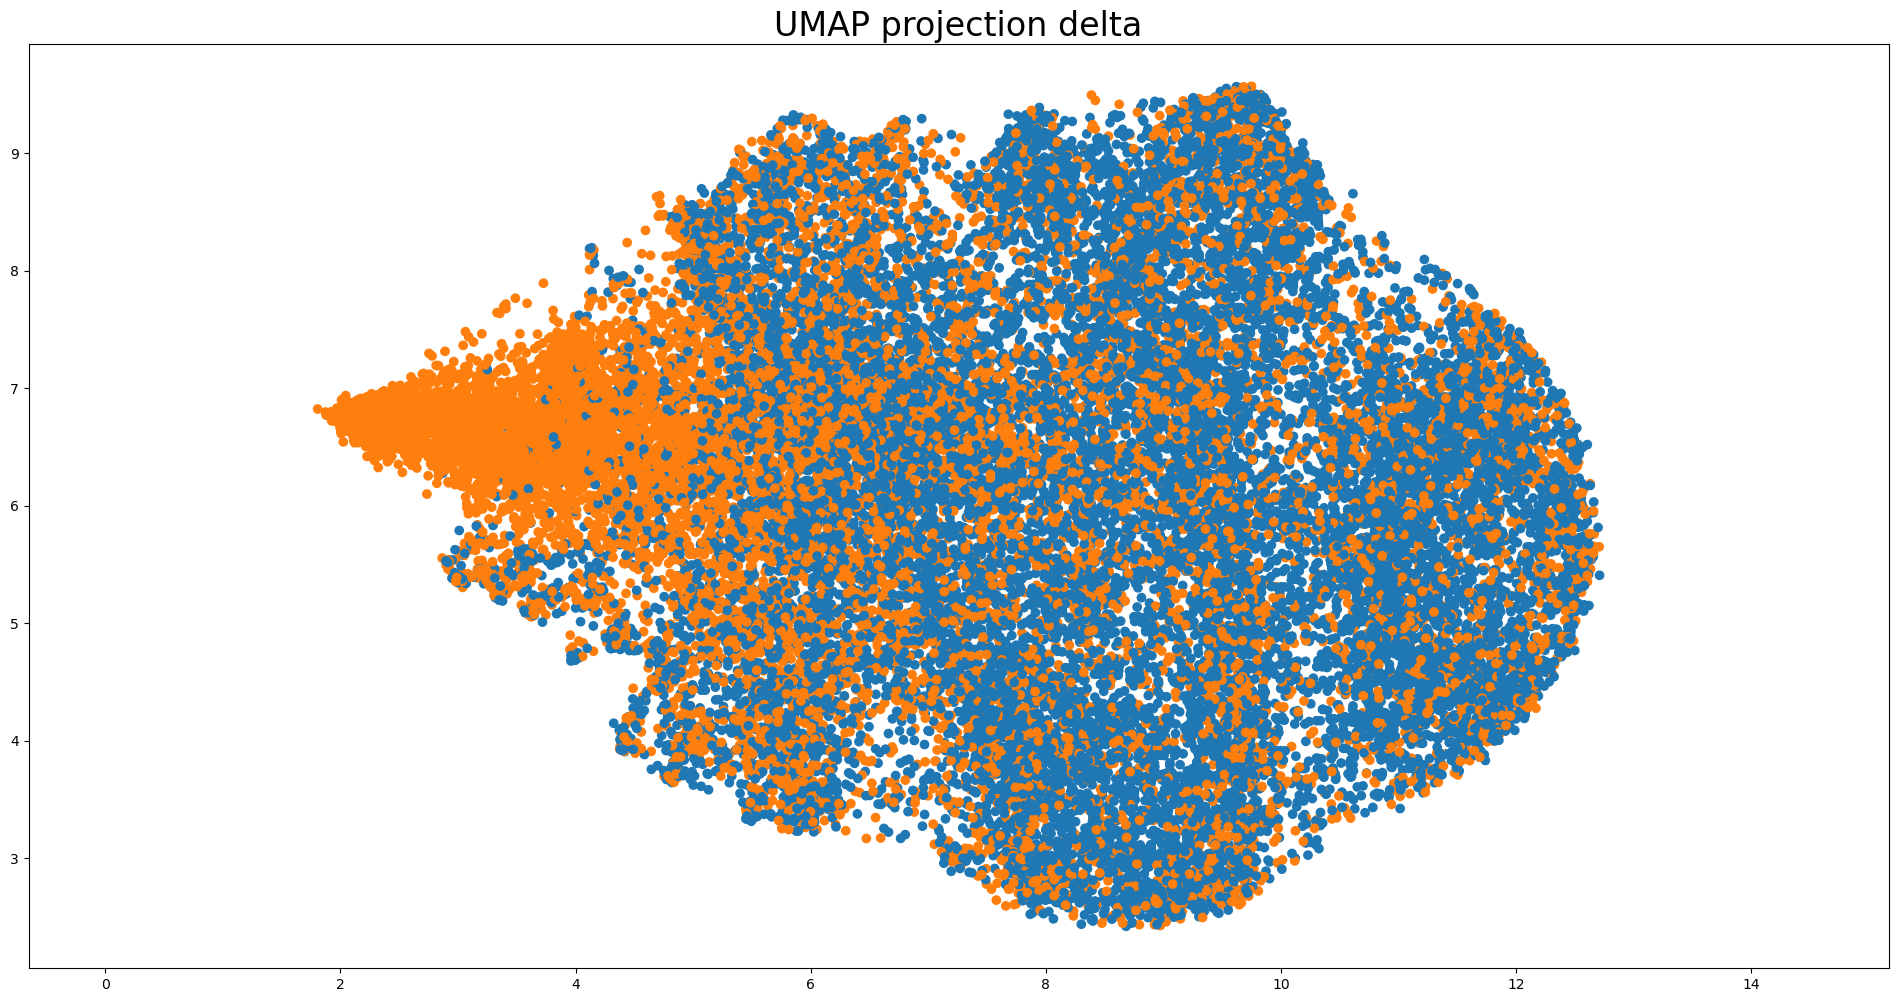

 17%|█▋        | 1/6 [00:16<01:20, 16.13s/it]

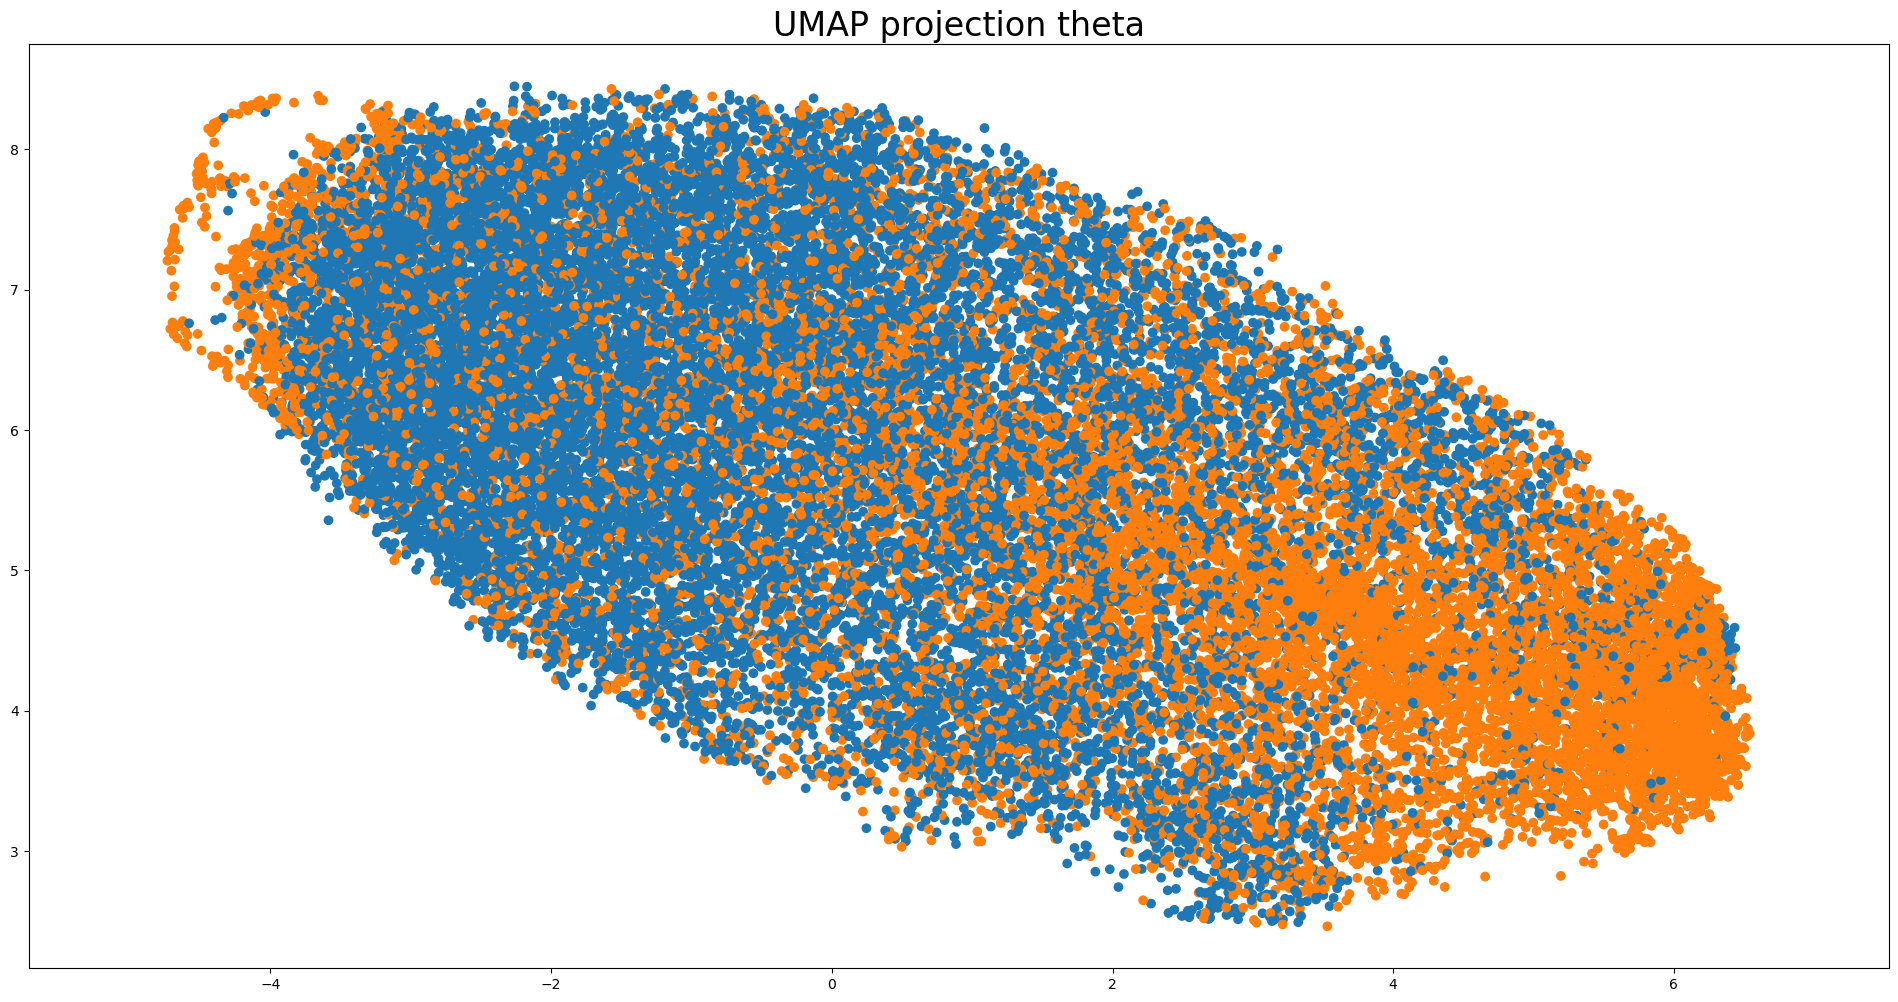

 33%|███▎      | 2/6 [00:20<00:37,  9.49s/it]

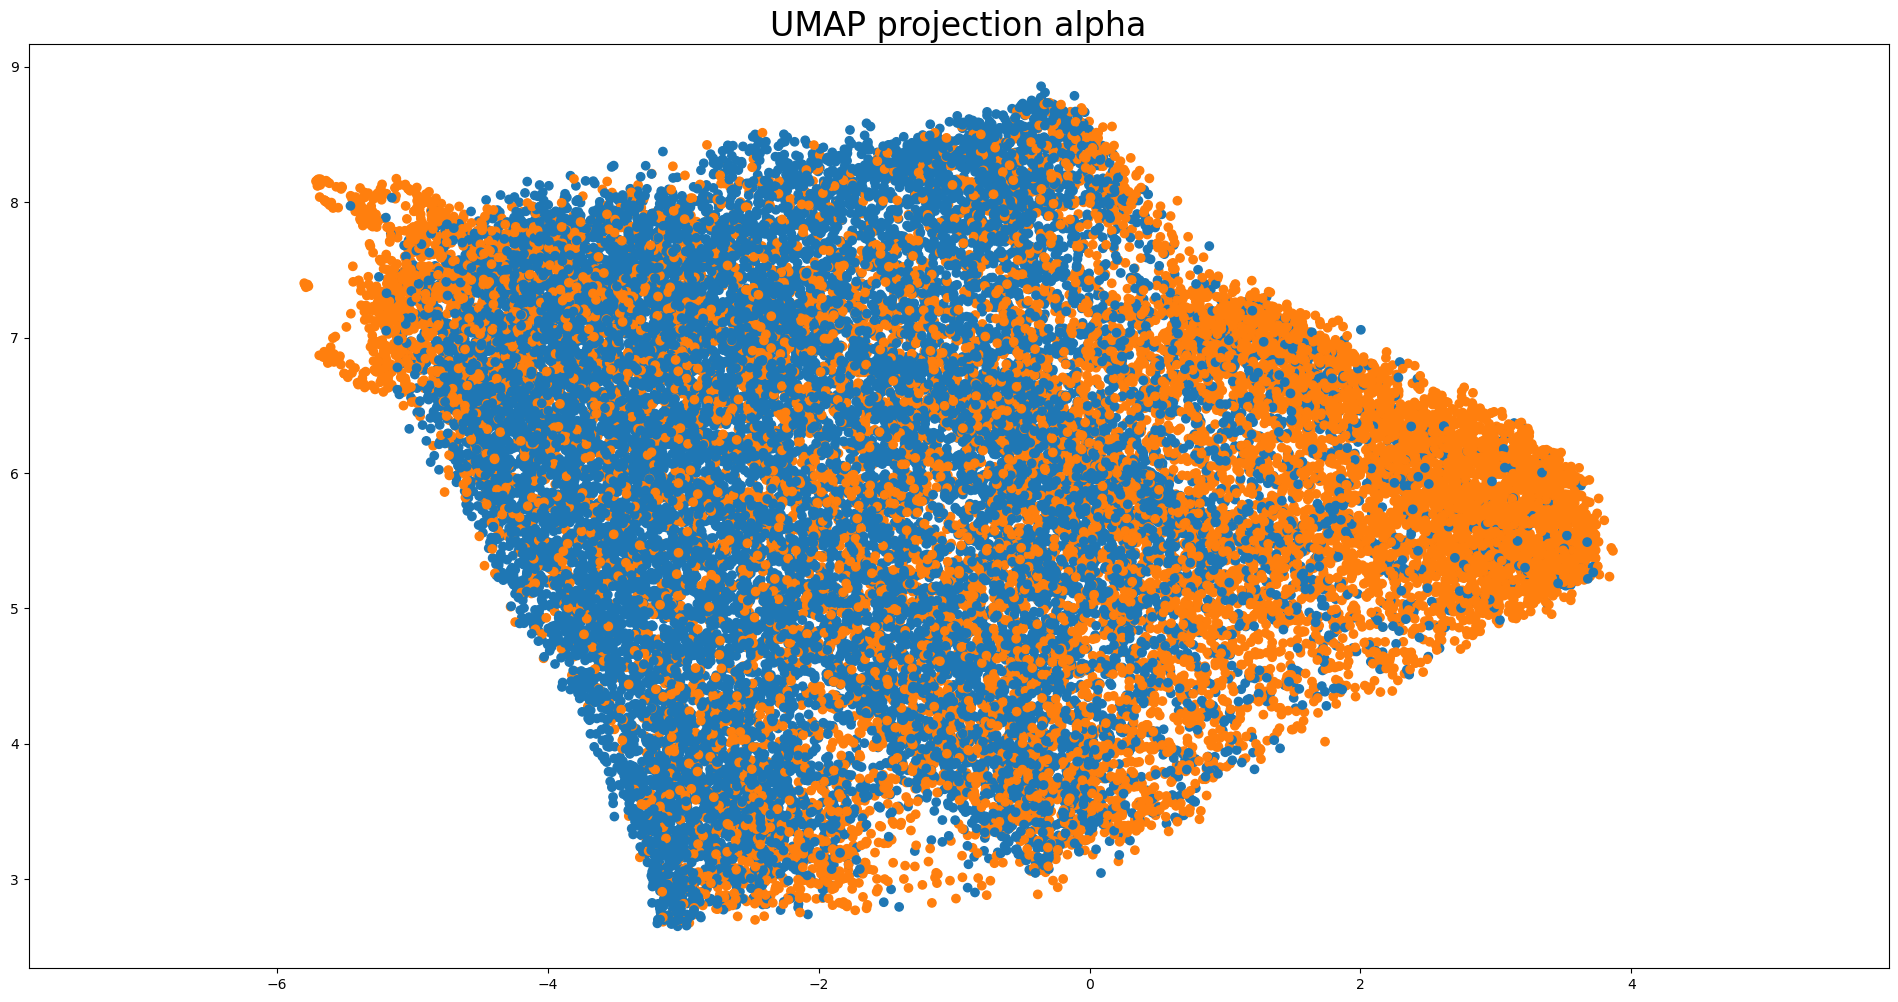

 50%|█████     | 3/6 [00:26<00:22,  7.49s/it]

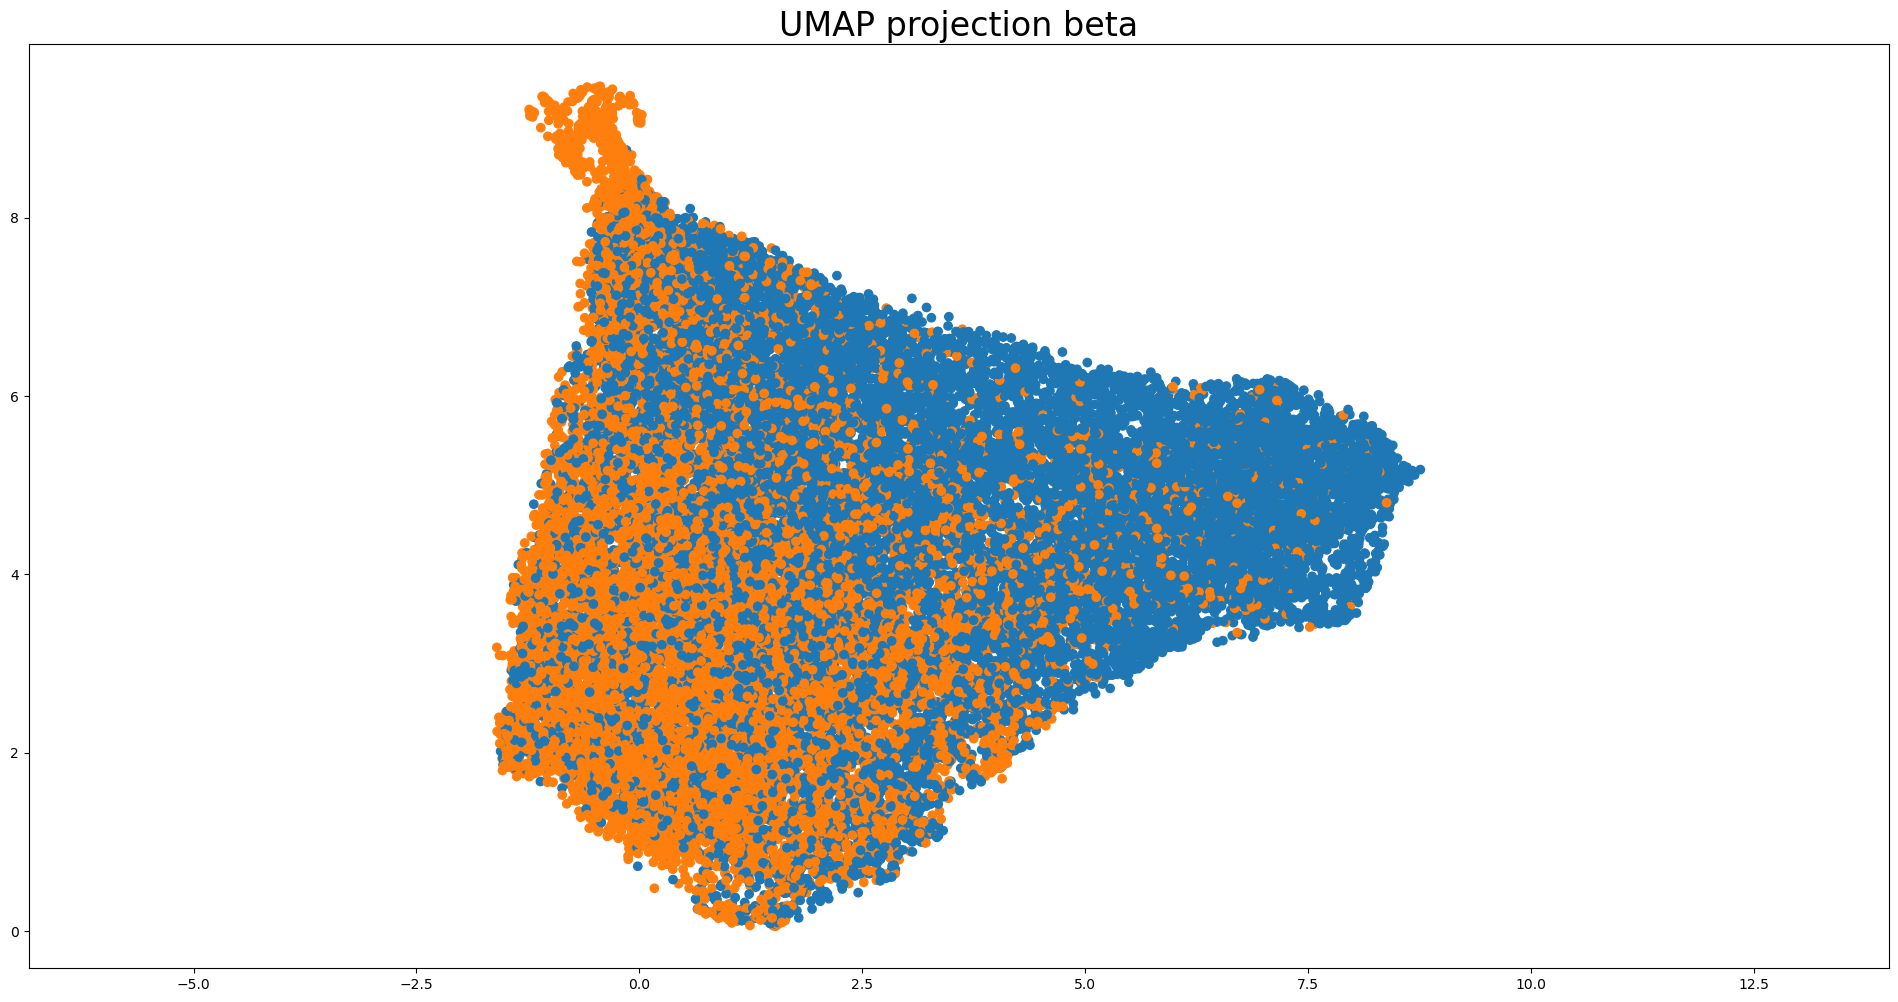

 67%|██████▋   | 4/6 [00:30<00:12,  6.39s/it]

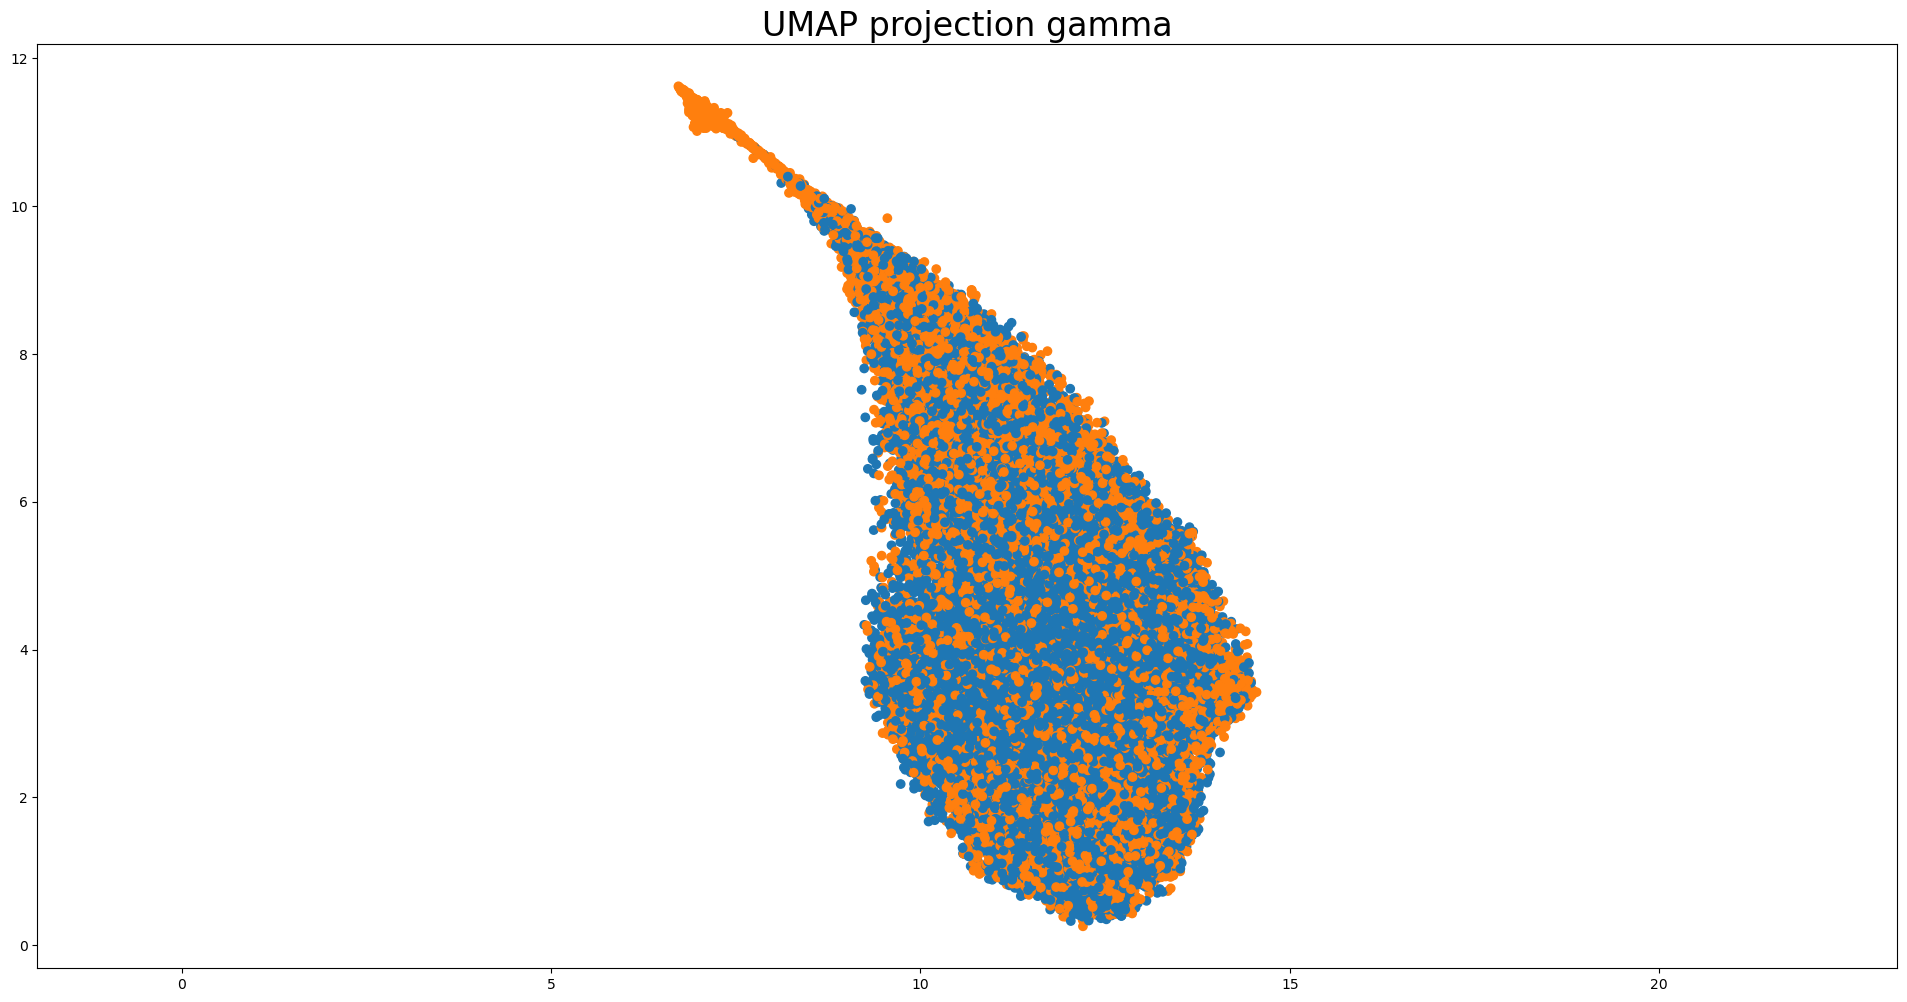

 83%|████████▎ | 5/6 [00:36<00:05,  5.97s/it]

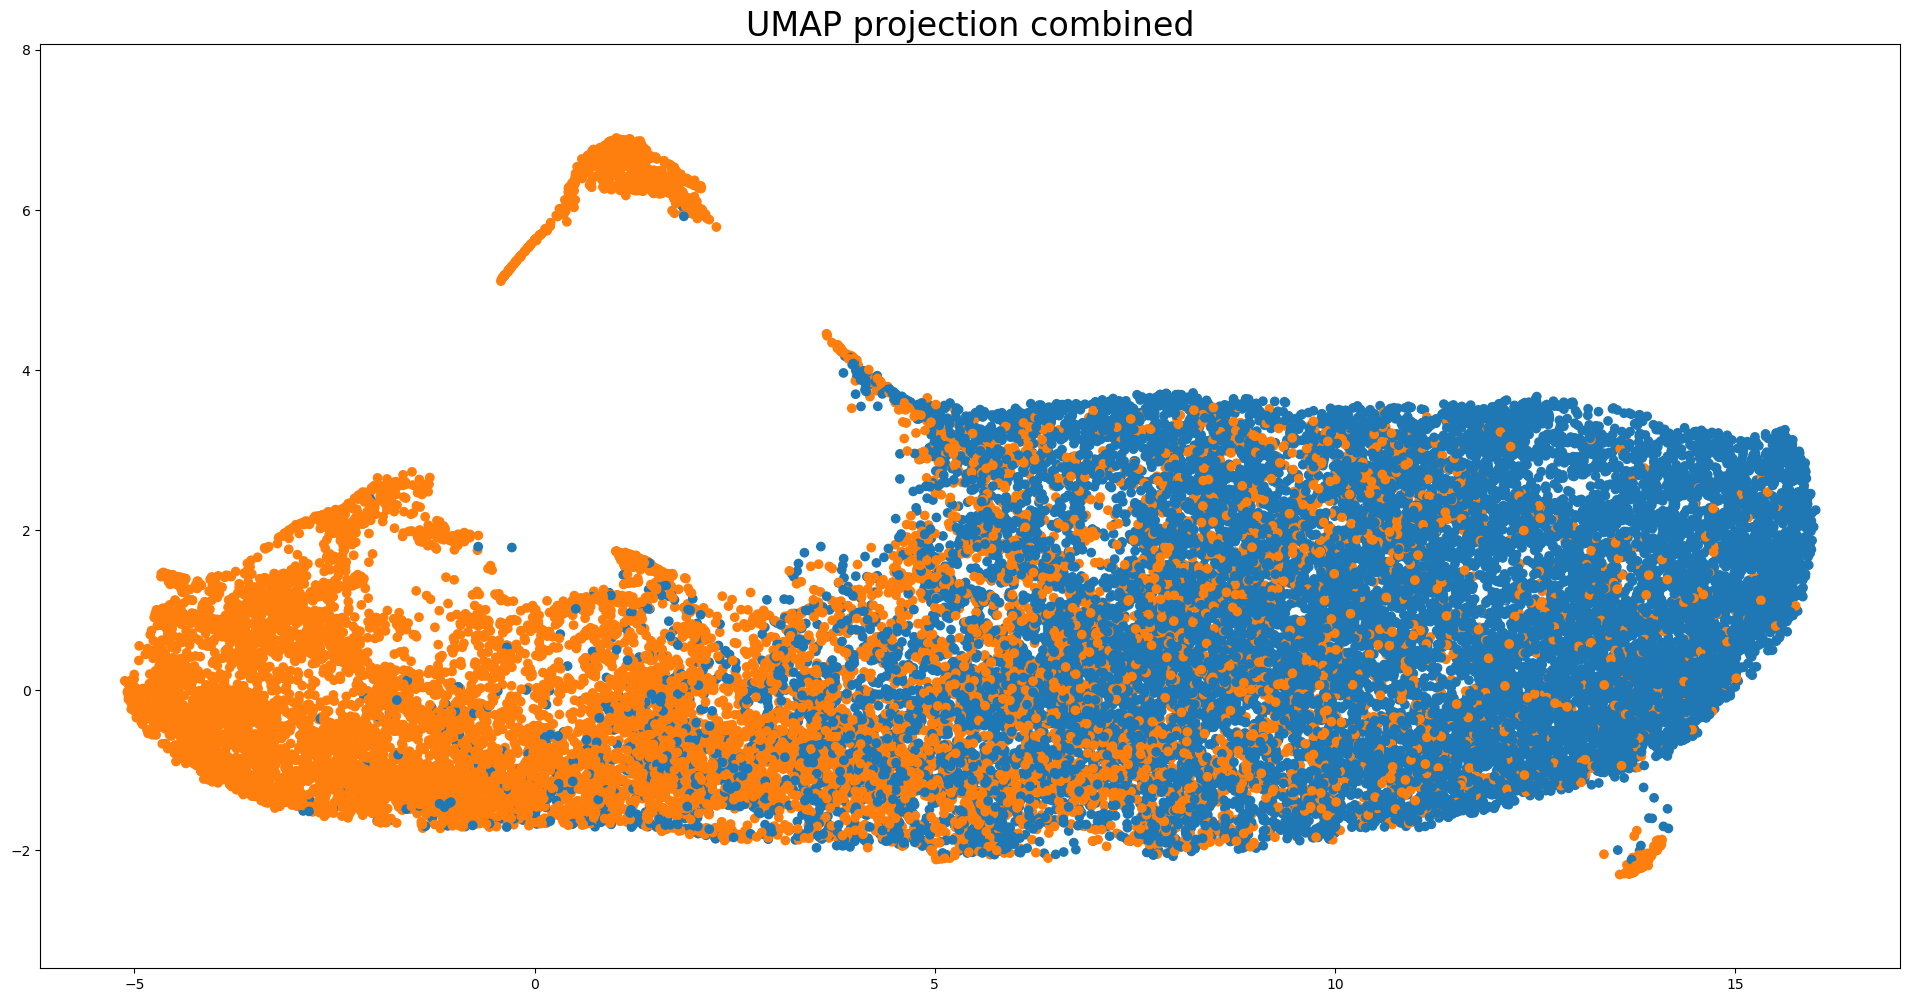

100%|██████████| 6/6 [00:40<00:00,  6.75s/it]


In [26]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma', 'combined']):
    if band == 'combined':
        embeddings = reducer2.fit_transform(combined_output_eval_all, job=-1)
    else:
        data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
        embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure(figsize=(24, 12))
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all])
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()

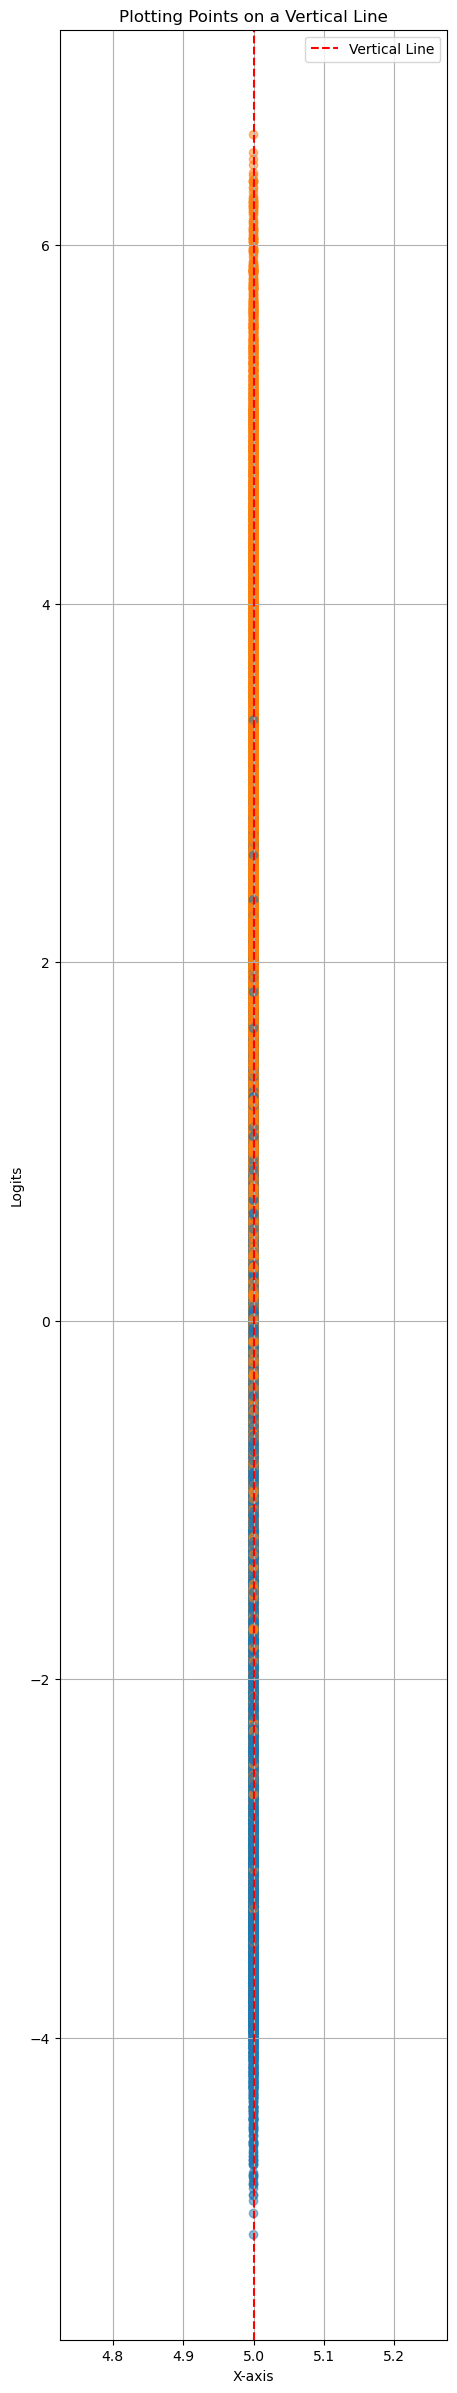

In [27]:
# Define the x-coordinate of the vertical line
x_value = 5

plt.figure(figsize=(5, 30))
# Plot the vertical line
plt.axvline(x=x_value, color='r', linestyle='--', label='Vertical Line')
plt.scatter(
    [x_value] * predictions.shape[0],
    predictions,
    c=[sns.color_palette()[x] for x in output_labels_eval_all],
    alpha=0.5)

# Customize the plot
plt.xlabel('X-axis')
plt.ylabel('Logits')
plt.title('Plotting Points on a Vertical Line')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

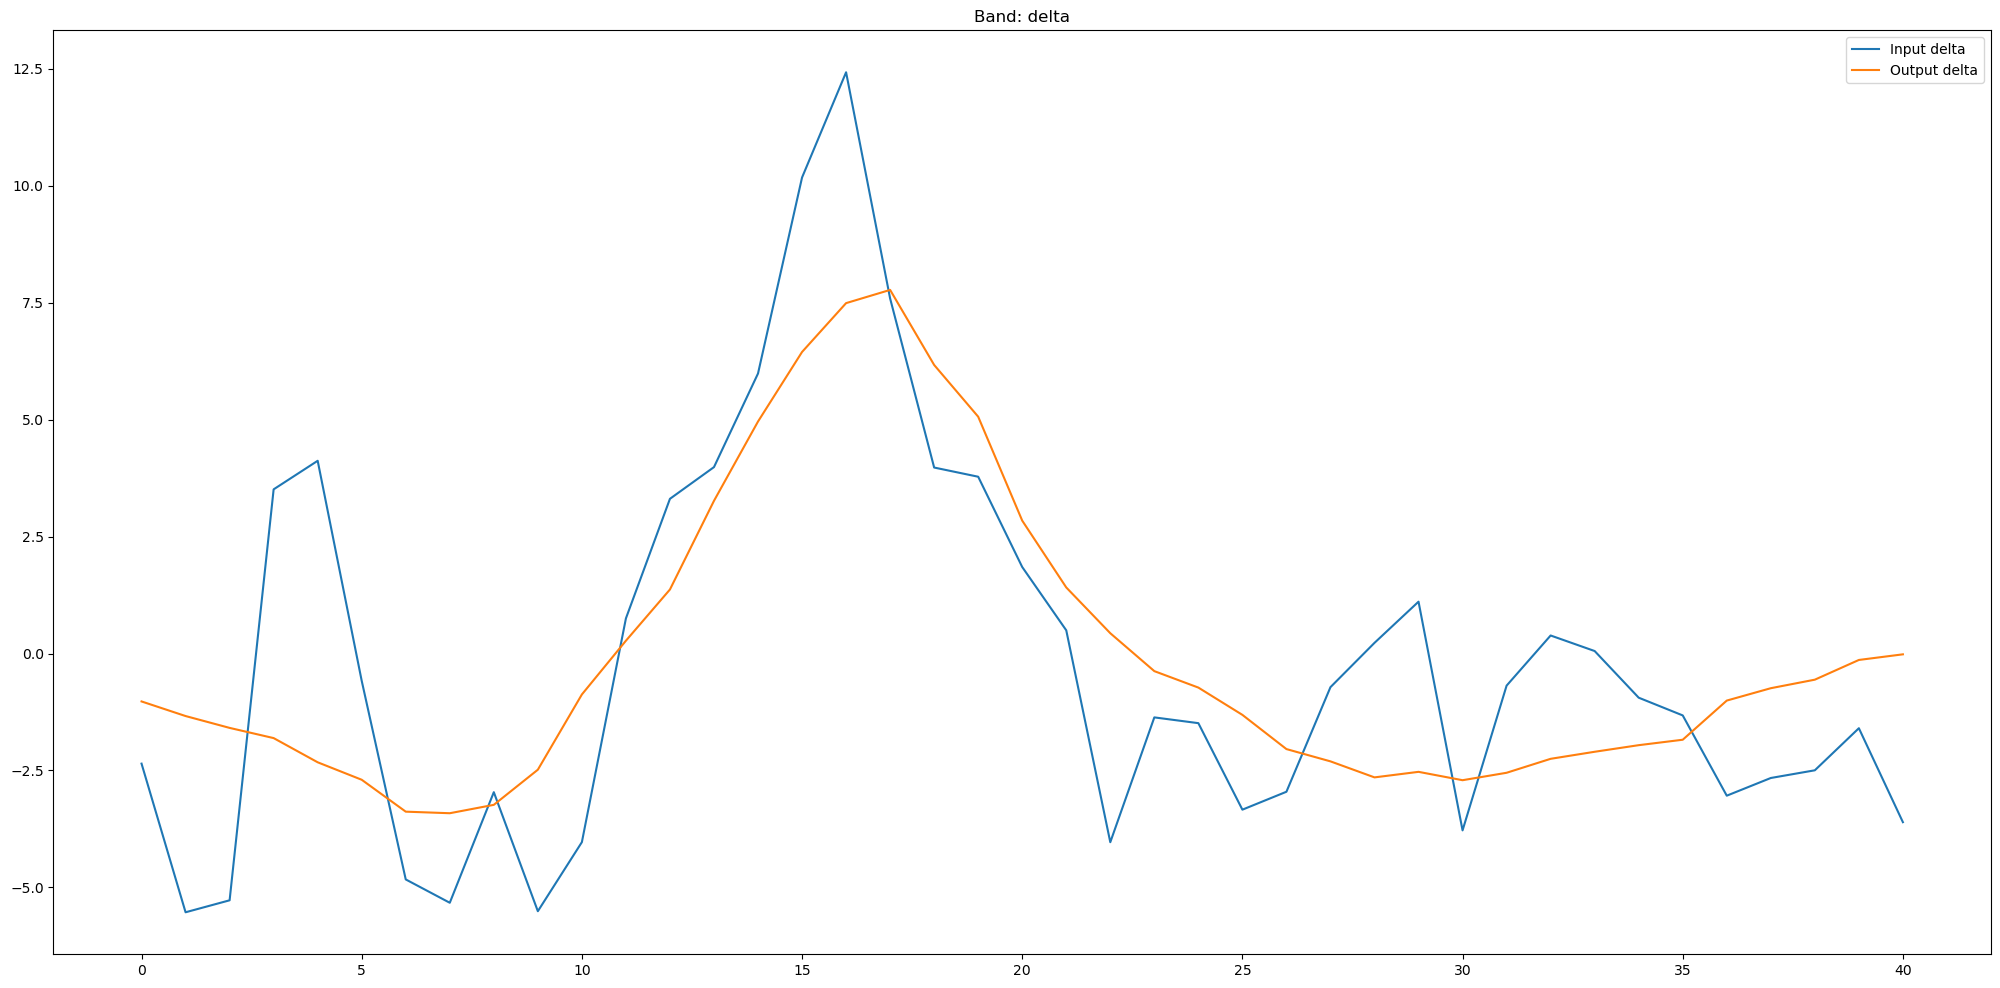

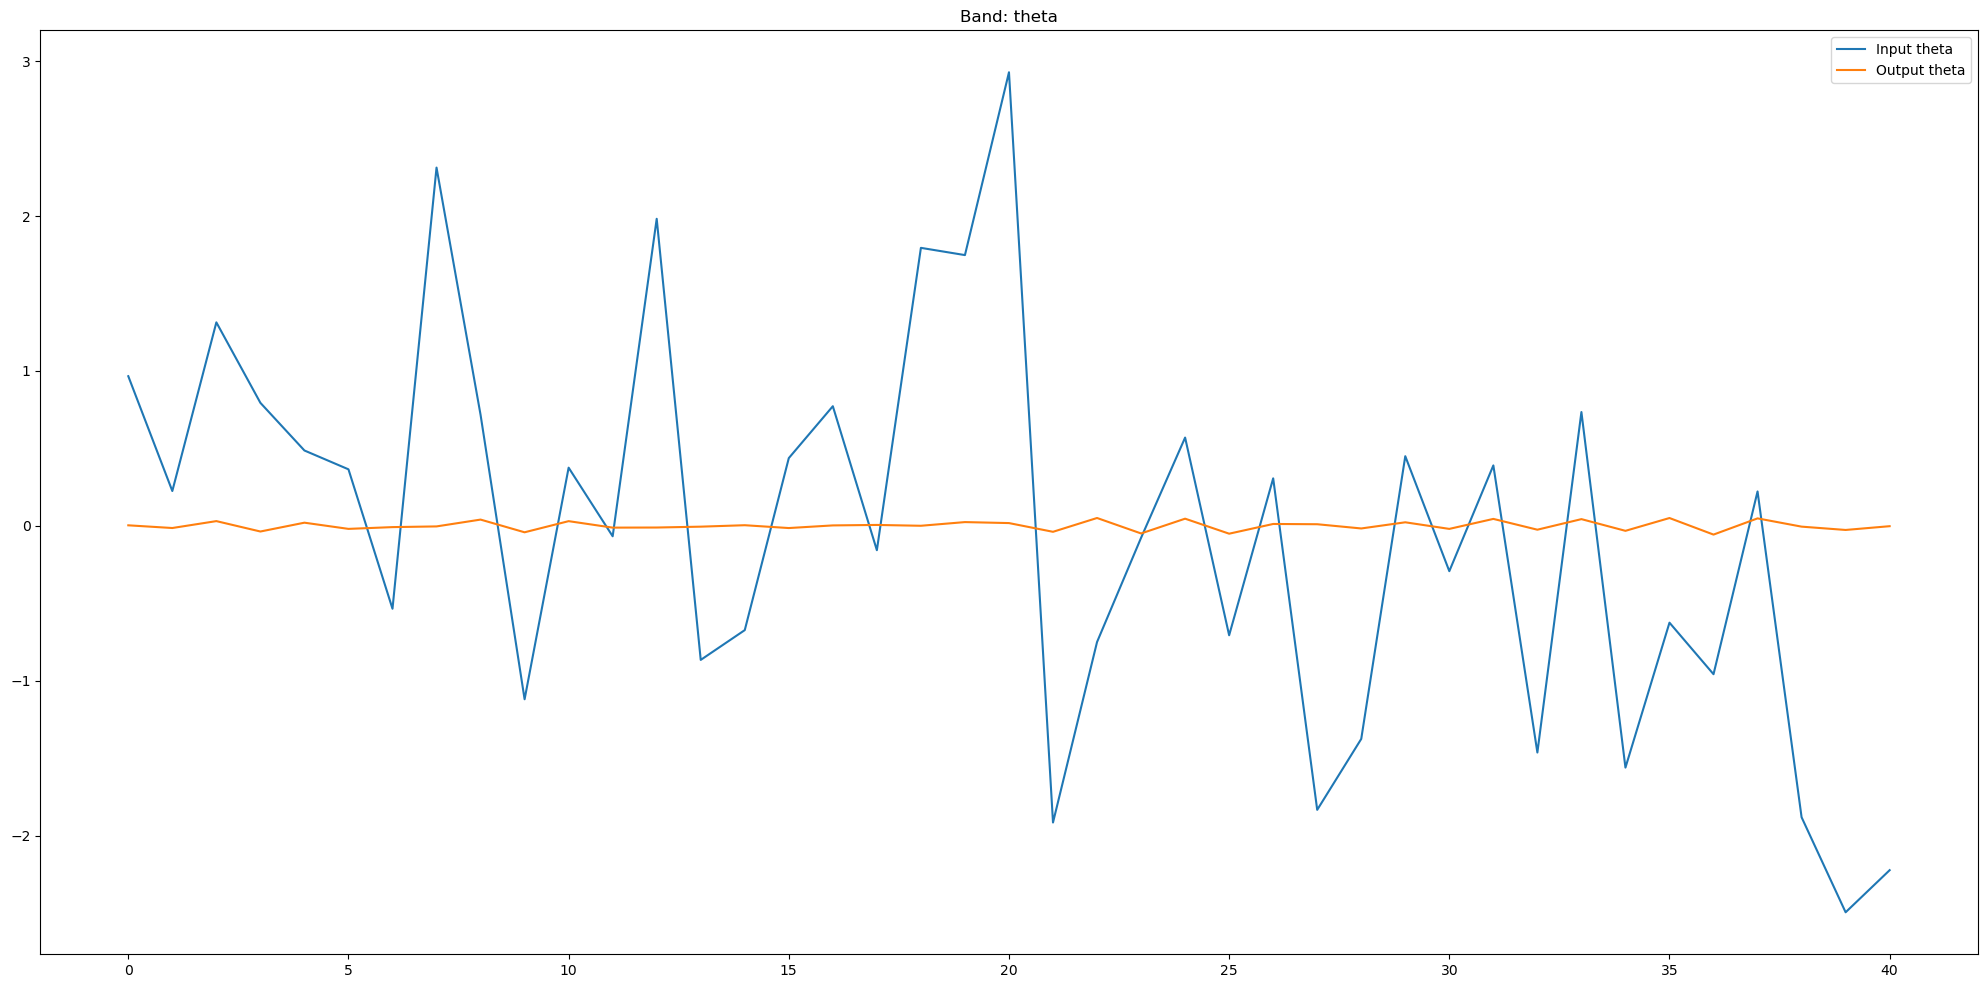

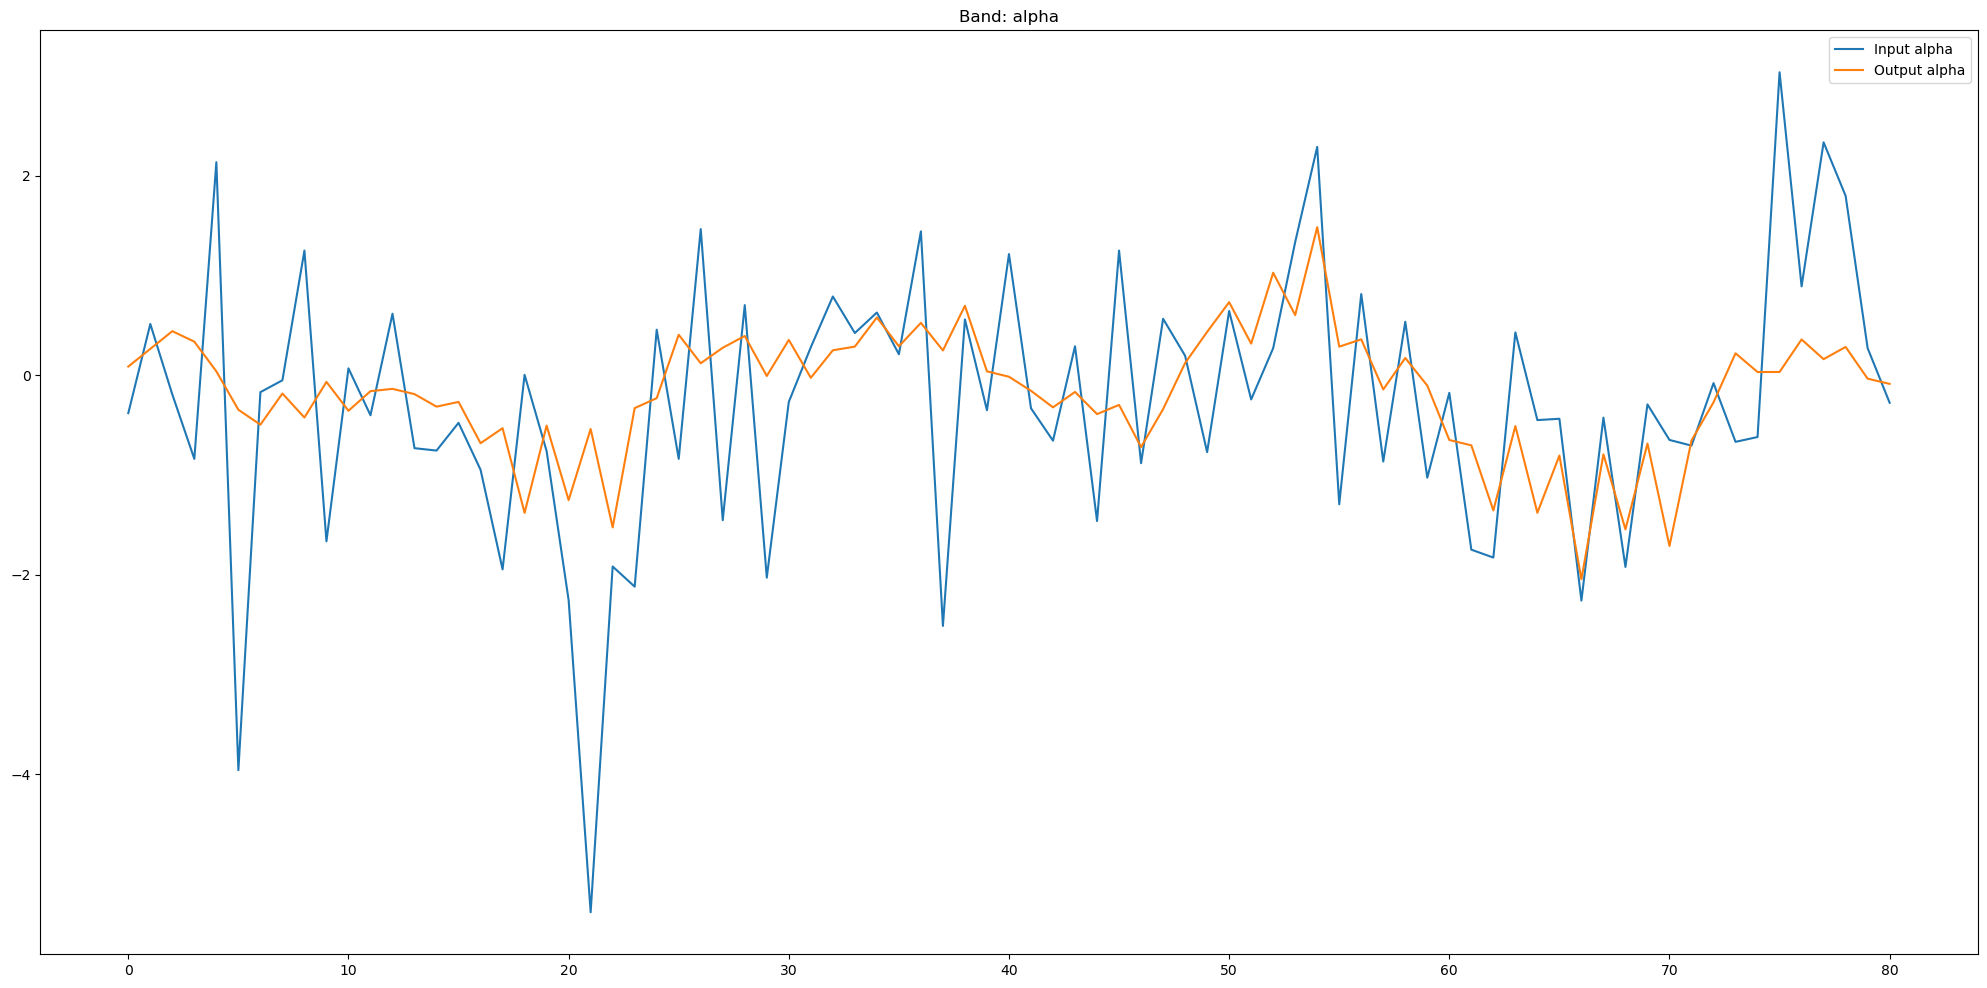

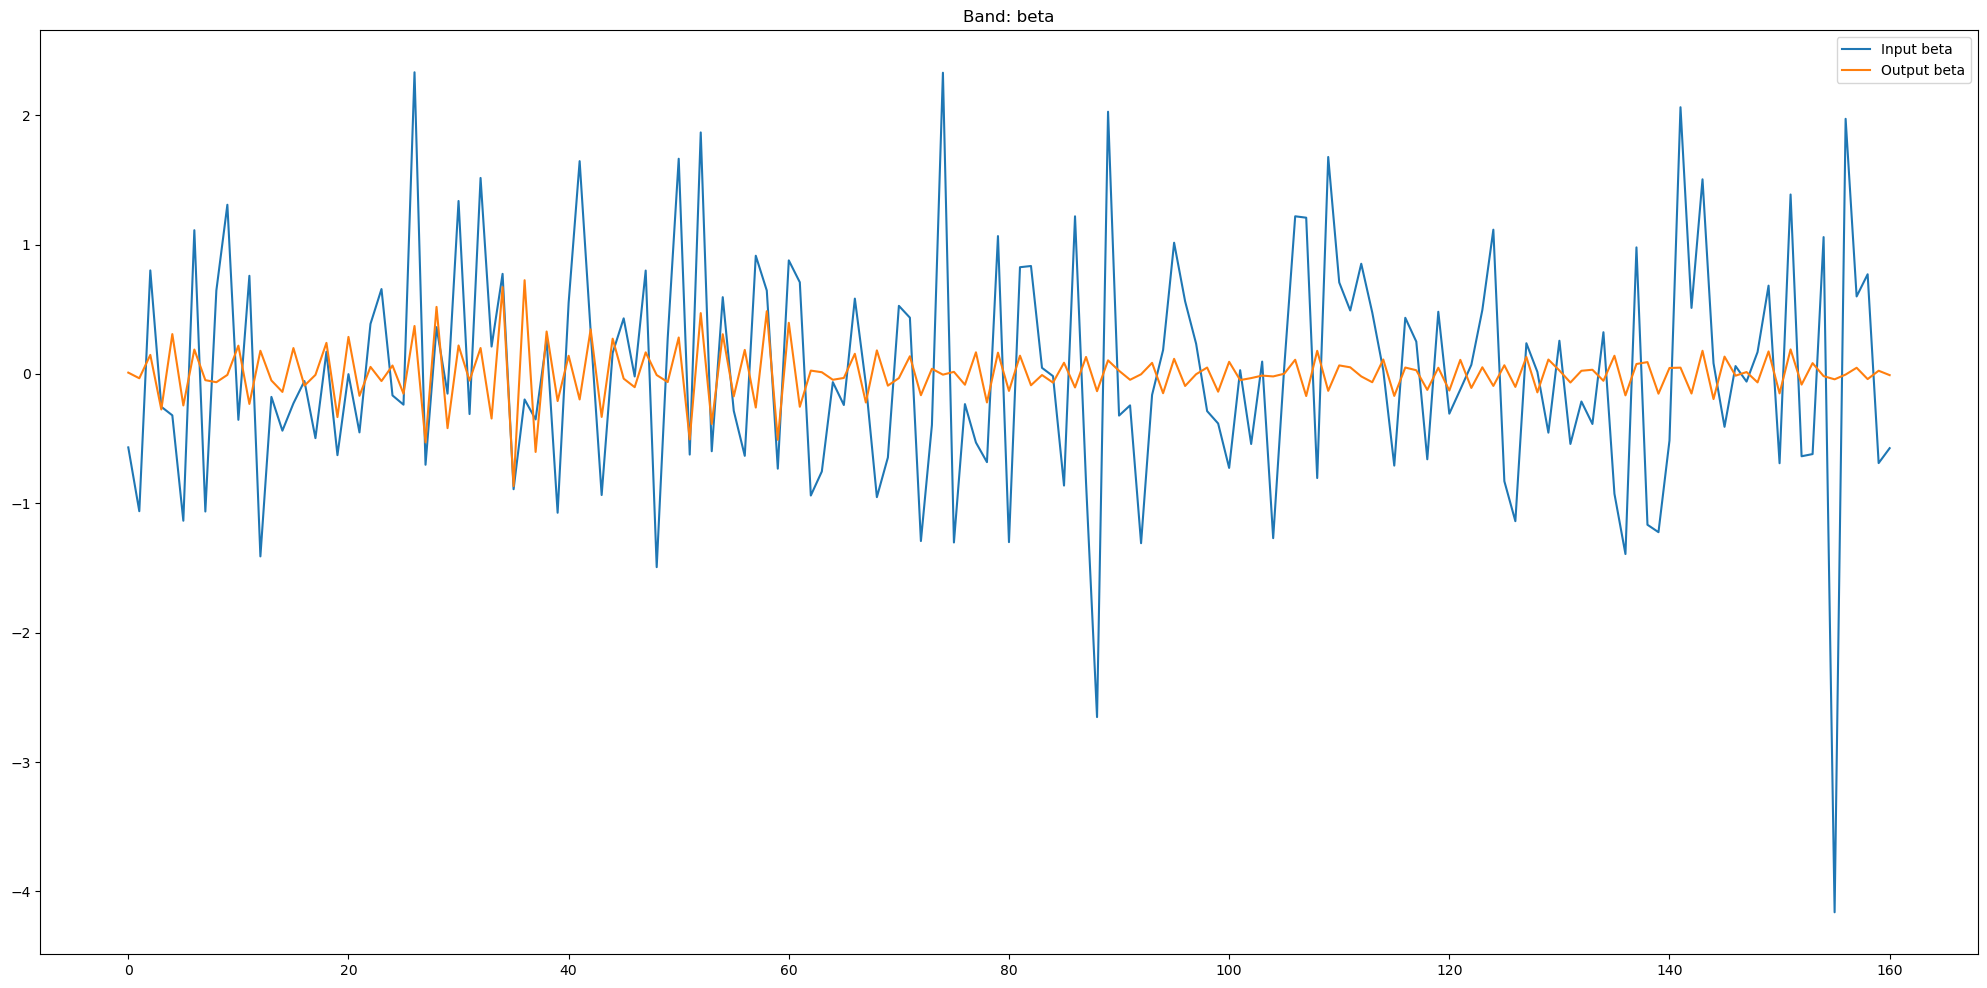

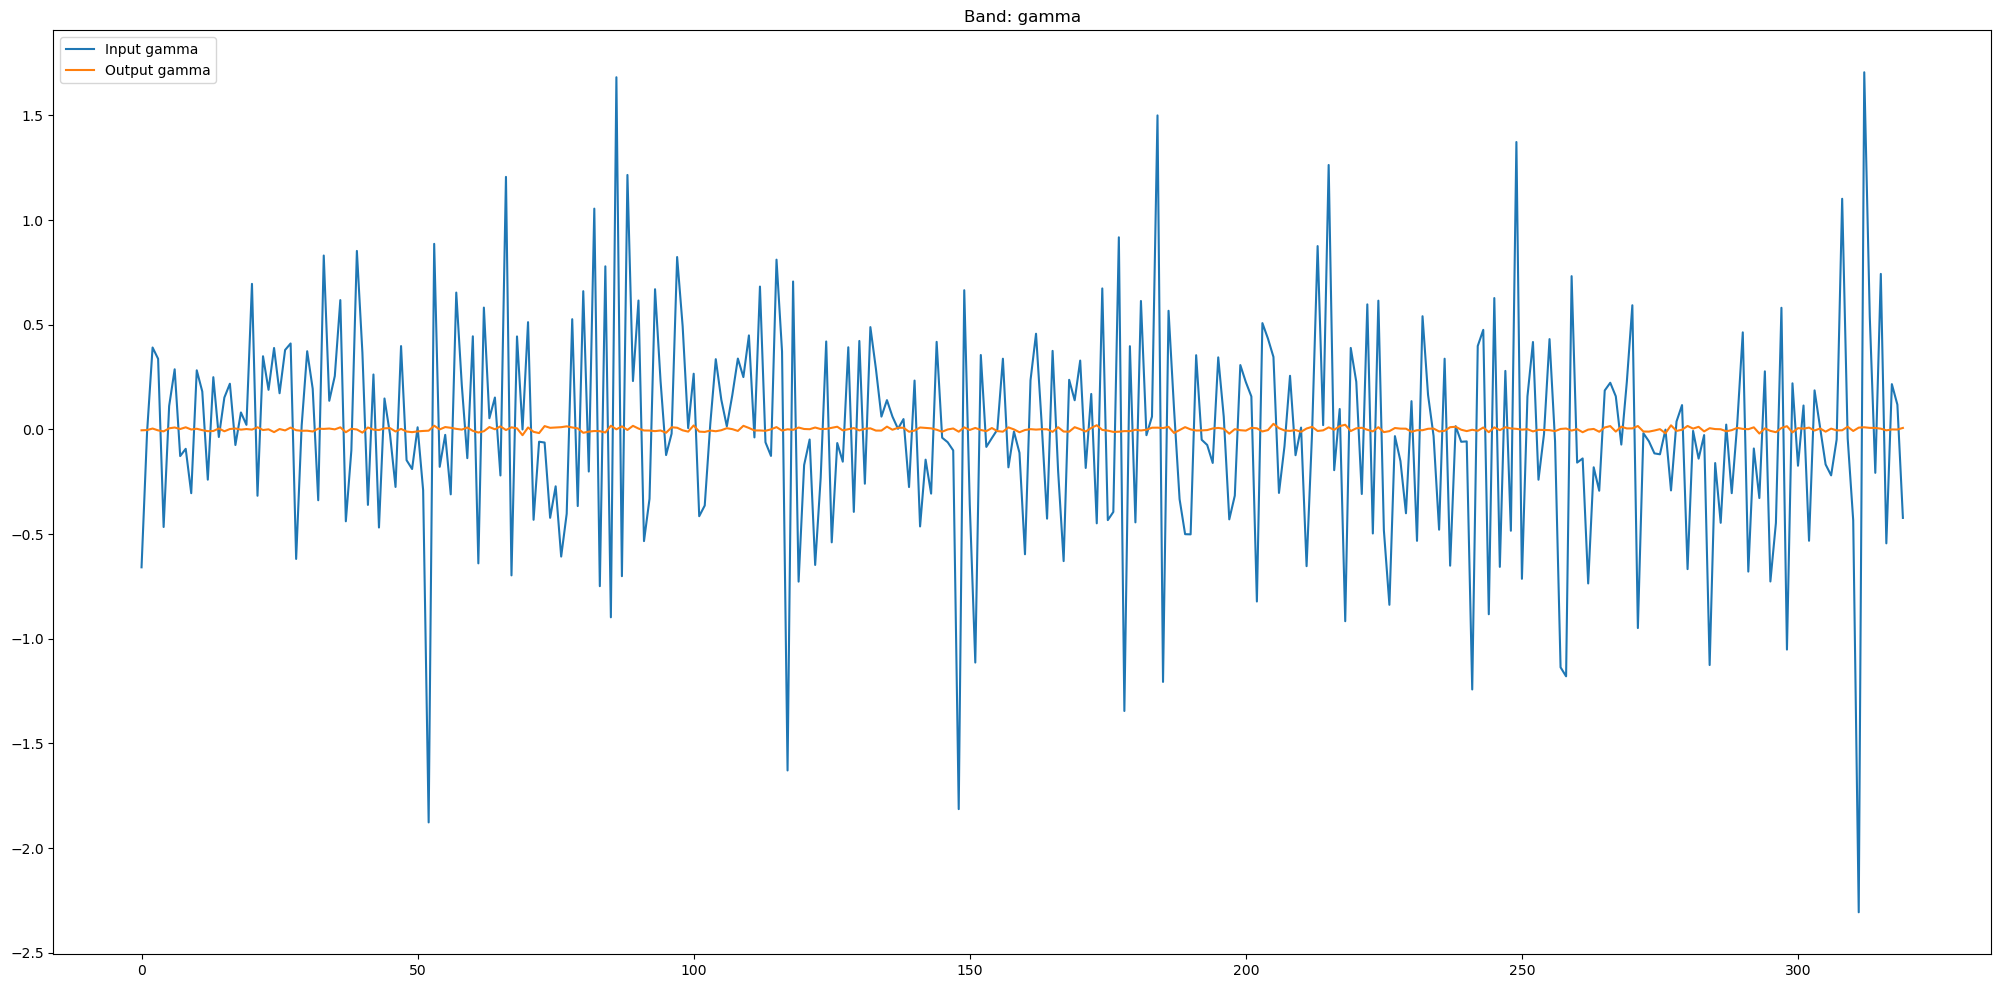

In [28]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(inputs[band][9,channel, :].cpu().detach().numpy(), label=f"Input {band}")
    plt.plot(encoder_outputs[band][1][9, channel, :].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()